In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [3]:
sns.cubehelix_palette(10, start=3, dark=0.2, light=0.8, hue=1, reverse=False)

[[0.9341098867875465, 0.7443380671004642, 0.7327970403599684],
 [0.9051349025890352, 0.6556488850554929, 0.6814560944023864],
 [0.865393086036878, 0.5698918201140944, 0.6437524015200796],
 [0.8123904973839382, 0.4892336358965068, 0.6148658313120196],
 [0.7451044313791337, 0.41520075485672664, 0.5893983637285835],
 [0.664020781443262, 0.3485789802462096, 0.5618100445856654],
 [0.5710735930894479, 0.28936228977318007, 0.5268584940263034],
 [0.46949075567837145, 0.23675331609249928, 0.4800171709455163],
 [0.3635545633696824, 0.18921548693966048, 0.41784872770365217],
 [0.2582902449485598, 0.14457415668696927, 0.3383120401060592]]

In [4]:
# optional parameters
# (this cell is tagged "parameters")

colors = sns.cubehelix_palette(10, start=3, dark=0.2, light=0.8, hue=1, reverse=False)
metric = 'txx'
location = [4, 1]
model_dict = {
    'BCC-CSM2-MR': colors[0],
    'CAFE': colors[1],
    'CMCC-CM2-SR5': colors[2],
    'CanESM5': colors[3],
    'EC-Earth3': colors[4],
    'IPSL-CM6A-LR': colors[9],
    'MIROC6': colors[6],
    'MPI-ESM1-2-HR': colors[7],
    'MRI-ESM2-0': colors[5],
    'NorCPM1': colors[8],
}  

In [5]:
assert "location" in locals(), "Must provide a location name"
assert "metric" in locals(), "Must provide a metric (rx1day or txx)"
assert "model_dict" in locals(), "Must provide a model dict"

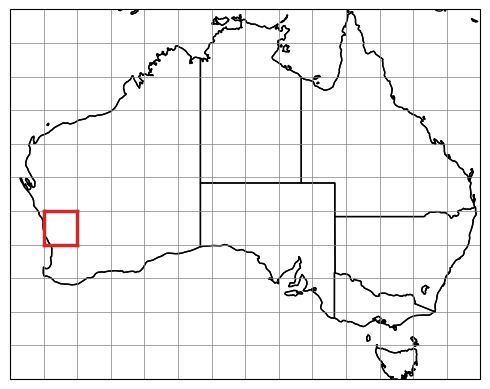

In [6]:
if type(location) == list:
    lat_index, lon_index = location
    utils.plot_grid_box(lat_index, lon_index)

## Analysis

In [7]:
def get_data(metric, location, model_dict):
    """Get data."""
    
    return_values_dict = {}
    gev_params_dict = {}
    sample_size_dict = {}

    da_obs = utils.get_obs_data(metric, location)
    da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)
    gev_params_obs_detrended = list(eva.fit_gev(da_obs_detrended.values))
    return_periods, return_values_obs = stability.return_curve(
        da_obs_detrended,
        'gev',
        params=gev_params_obs_detrended,
    )
    return_values_dict[('obs', 'AGCD')] = return_values_obs
    
    for model in model_dict:
        print(model)
        da_model_stacked = utils.get_model_data(metric, model, location)
        da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)
        da_model_detrended_stacked_bc_mean = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)
        da_model_detrended_stacked_bc_quantile = utils.quantile_correction(da_model_detrended_stacked, da_obs_detrended, metric)
        gev_model_detrended = list(eva.fit_gev(da_model_detrended_stacked.values))
        gev_model_detrended_bc_mean = list(eva.fit_gev(da_model_detrended_stacked_bc_mean.values))
        gev_model_detrended_bc_quantile = list(eva.fit_gev(da_model_detrended_stacked_bc_quantile.values))
        return_periods, return_values_model_raw = stability.return_curve(
            da_model_detrended_stacked,
            'gev',
            params=gev_model_detrended,
        )
        return_periods, return_values_model_bc_mean = stability.return_curve(
            da_model_detrended_stacked_bc_mean,
            'gev',
            params=gev_model_detrended_bc_mean,
        )
        return_periods, return_values_model_bc_quantile = stability.return_curve(
            da_model_detrended_stacked_bc_quantile,
            'gev',
            params=gev_model_detrended_bc_quantile,
        )
        return_values_dict[('model-raw', model)] = return_values_model_raw
        return_values_dict[('model-bc-mean', model)] = return_values_model_bc_mean
        gev_params_dict[('model-bc-mean', model)] = gev_model_detrended_bc_mean
        sample_size_dict[('model-bc-mean', model)] = len(da_model_detrended_stacked_bc_mean.values)
        return_values_dict[('model-bc-quantile', model)] = return_values_model_bc_quantile

    return_values_df = pd.DataFrame(return_values_dict)
    return_values_df.index = return_periods
    return_values_df = return_values_df.drop([1.0])
    
    return return_values_df, gev_params_dict, sample_size_dict

In [64]:
def plot_dataset_uncertainty(
    ax,
    metric,
    model_dict,
    return_df,
    ylim=[],
    outfile=None,
):
    """Plot dataset uncertainty."""

    return_periods = return_df.index.values
    rv_1000 = []
    for model, color in model_dict.items():
        bc_mean_return_values = return_df[('model-bc-mean', model)].values
        bc_mean_rv_1000 = bc_mean_return_values[7500]
        rv_1000.append(bc_mean_rv_1000)
        ax.plot(
            return_periods,
            bc_mean_return_values,
            label=f'{model}',
            color=color,
            linewidth=3.0,
        )

    rv_min = np.min(rv_1000)
    rv_max = np.max(rv_1000)
    ax.plot([return_periods[7500], return_periods[7500]], [rv_min, rv_max], color='0.2', linewidth=3.0, marker='o')
    
    ax.legend()#bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(' ')
    ax.set_title('(c) dataset uncertainty')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

In [65]:
def plot_bias_correction_uncertainty(
    ax,
    metric,
    model_dict,
    return_df,
    ylim=[],
    outfile=None,
):
    """Plot return curves."""

    return_periods = return_df.index.values

    for model, color in model_dict.items():
        bc_mean_return_values = return_df[('model-bc-mean', model)].values
        bc_mean_rv_1000 = bc_mean_return_values[7500]
        ax.plot(
            return_periods,
            bc_mean_return_values,
            label=f'{model} (mean)',
            color=color,
            linewidth=3.0,
        )
        
        bc_quantile_return_values = return_df[('model-bc-quantile', model)].values
        bc_quantile_rv_1000 = bc_quantile_return_values[7500]
        ax.plot(
            return_periods,
            bc_quantile_return_values,
            label=f'{model} (quantile)',
            color=color,
            linestyle='--',
            linewidth=3.0,
        )
        ax.plot(
            [return_periods[7500], return_periods[7500]],
            [bc_mean_rv_1000, bc_quantile_rv_1000],
            color='0.2',
            linewidth=3.0,
            marker='o'
        )
        
    ax.plot(
            return_periods,
            return_df[('obs', 'AGCD')].values,
            label='AGCD',
            color='black',
            linewidth=3.0,
        )
    
    ax.legend()#bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(' ')
    ax.set_title('(b) bias correction uncertainty')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

In [66]:
def plot_eva_uncertainty(
    ax,
    metric,
    model_dict,
    gev_params_dict,
    sample_size_dict,
    ylim=[],
    n_bootstraps=10,
    outfile=None,
):
    """PLot sampling uncertainty."""

    return_periods = return_df.index.values
    
    for model, color in model_dict.items():
        original_gev_params = gev_params_dict[('model-bc-mean', model)]
        shape, loc, scale = original_gev_params
        sample_size = sample_size_dict[('model-bc-mean', model)]
        rp1000 = []
        for i in range(n_bootstraps):
            boot_data = gev.rvs(shape, loc=loc, scale=scale, size=sample_size)
            boot_gev_params = list(eva.fit_gev(boot_data))
            return_periods, return_values = stability.return_curve(boot_data, 'gev', params=boot_gev_params)
            label = model if i == 0 else None
            rp1000.append(return_values[7500])
            ax.plot(return_periods, return_values, label=label, color=color, linewidth=3.0)
        rp_min = np.min(rp1000)
        rp_max = np.max(rp1000)
        ax.plot([return_periods[7500], return_periods[7500]], [rp_min, rp_max], color='0.2', linewidth=3.0, marker='o')
        
    ax.legend()#bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel('TXx ($^\circ$C)')
    ax.set_title('(a) sampling uncertainty')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

## Plots

In [11]:
return_df, gev_params_dict, sample_size_dict = get_data(metric, location, model_dict)

BCC-CSM2-MR
CAFE
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


In [12]:
return_df

obs   model-raw model-bc-mean model-bc-quantile  \
                   AGCD BCC-CSM2-MR   BCC-CSM2-MR       BCC-CSM2-MR   
1.000922      38.553673   40.333203     39.552260         38.853849   
1.001844      38.811153   40.503826     39.722878         39.068495   
1.002767      38.970900   40.610741     39.829790         39.202665   
1.003691      39.088853   40.690221     39.909267         39.302237   
1.004616      39.183213   40.754138     39.973183         39.382208   
...                 ...         ...           ...               ...   
9963.222749   46.425242   47.920146     47.138682         47.466260   
9972.404362   46.425316   47.920325     47.138860         47.466423   
9981.594436   46.425390   47.920503     47.139039         47.466586   
9990.792980   46.425465   47.920682     47.139217         47.466748   
10000.000000  46.425539   47.920860     47.139395         47.466911   

              model-raw model-bc-mean model-bc-quantile    model-raw  \
                   CAFE          CAFE              CAFE CMCC-CM2-SR5   
1.000922      37.699016     38.268304         38.814529    36.889785   
1.001844      37.936721     38.506966         39.019962    37.085464   
1.002767      38.085694     38.656512         39.148857    37.207846   
1.003691      38.196450     38.767681         39.244760    37.298706   
1.004616      38.285527     38.857081         39.321938    37.371701   
...                 ...           ...               ...          ...   
9963.222749   48.337025     48.867906         48.478752    44.922819   
9972.404362   48.337279     48.868155         48.479006    44.922978   
9981.594436   48.337532     48.868404         48.479260    44.923138   
9990.792980   48.337786     48.868653         48.479514    44.923298   
10000.000000  48.338039     48.868901         48.479768    44.923458   

             model-bc-mean model-bc-quantile  ...                model-raw  \
              CMCC-CM2-SR5      CMCC-CM2-SR5  ...     MIROC6 MPI-ESM1-2-HR   
1.000922         39.143542         38.802113  ...  38.636920     39.686642   
1.001844         39.339230         39.020107  ...  38.868884     39.882203   
1.002767         39.461618         39.156336  ...  39.013633     40.004752   
1.003691         39.552482         39.257420  ...  39.120932     40.095858   
1.004616         39.625481         39.338595  ...  39.207031     40.169128   
...                    ...               ...  ...        ...           ...   
9963.222749      47.176819         47.465383  ...  47.343780     48.406288   
9972.404362      47.176978         47.465544  ...  47.343921     48.406494   
9981.594436      47.177138         47.465704  ...  47.344062     48.406700   
9990.792980      47.177298         47.465865  ...  47.344204     48.406907   
10000.000000     47.177458         47.466025  ...  47.344345     48.407113   

             model-bc-mean model-bc-quantile  model-raw model-bc-mean  \
             MPI-ESM1-2-HR     MPI-ESM1-2-HR MRI-ESM2-0    MRI-ESM2-0   
1.000922         39.054805         38.874786  41.433597     39.272997   
1.001844         39.250362         39.084440  41.611157     39.450558   
1.002767         39.372910         39.215654  41.722625     39.562028   
1.003691         39.464015         39.313117  41.805594     39.644998   
1.004616         39.537284         39.391446  41.872383     39.711787   
...                    ...               ...        ...           ...   
9963.222749      47.774444         47.732918  49.998654     47.838611   
9972.404362      47.774650         47.733106  49.998890     47.838848   
9981.594436      47.774857         47.733293  49.999126     47.839084   
9990.792980      47.775063         47.733480  49.999362     47.839320   
10000.000000     47.775269         47.733668  49.999598     47.839556   

             model-bc-quantile  model-raw model-bc-mean model-bc-quantile  
                    MRI-ESM2-0    NorCPM1       NorCPM1           NorCPM1  
1.000922             38.917128  33.879021 

In [28]:
return_df.filter(like='model-bc').var(axis=1).iloc[7500]

np.float64(0.16814124882166956)

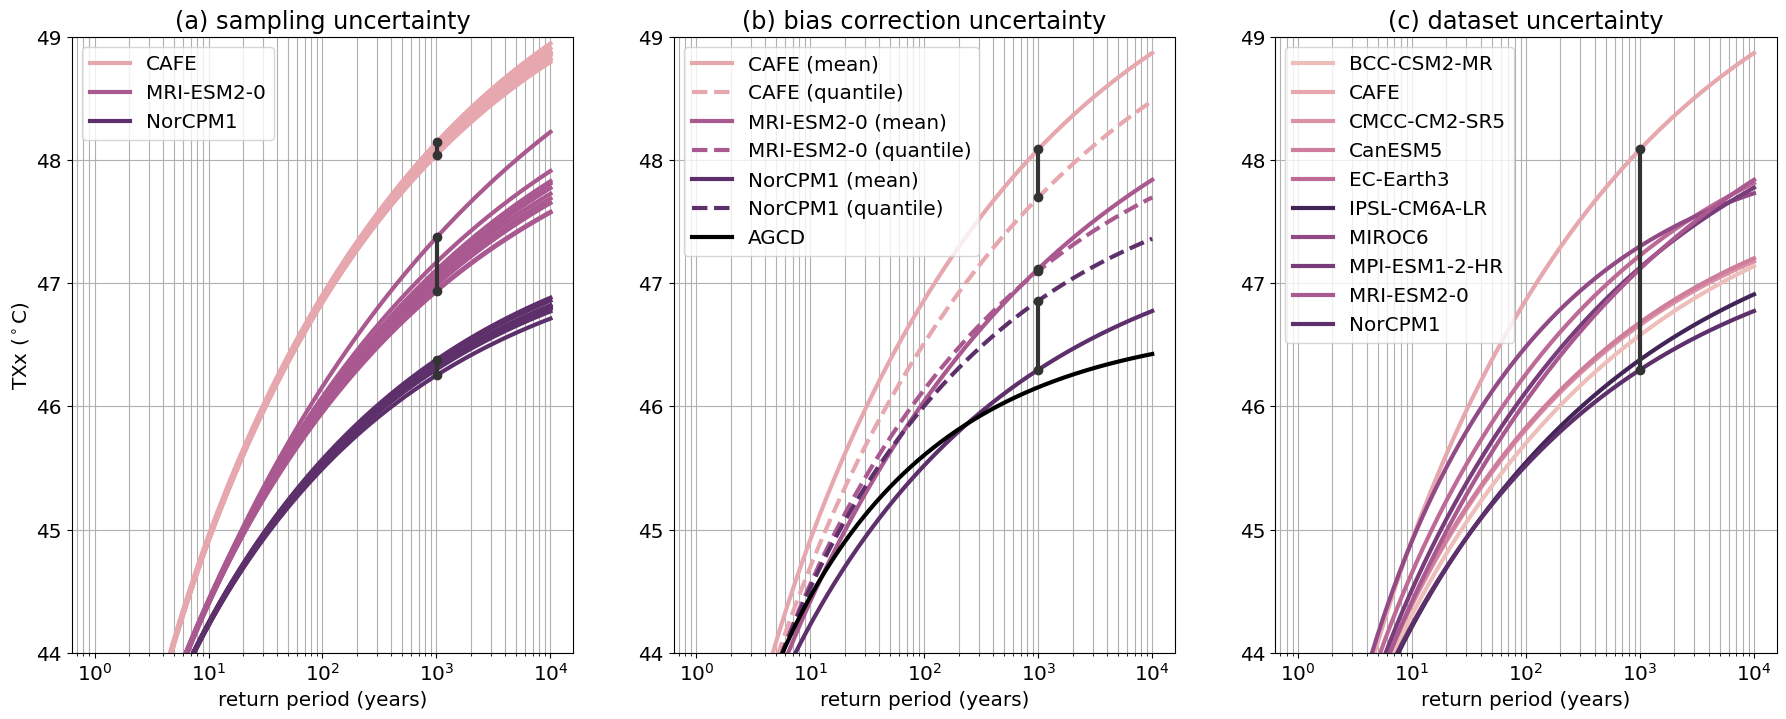

In [67]:
fig = plt.figure(figsize=[22, 8])

ylim = [44, 49]
model_subset = ['CAFE', 'MRI-ESM2-0', 'NorCPM1']

ax1 = fig.add_subplot(131)
eva_model_dict = {key: model_dict[key] for key in model_subset if key in model_dict}
plot_eva_uncertainty(
    ax1,
    metric,
    eva_model_dict,
    gev_params_dict,
    sample_size_dict,
    ylim=ylim,
    n_bootstraps=10,
    outfile=None,
)

ax2 = fig.add_subplot(132)
bias_model_dict = {key: model_dict[key] for key in model_subset if key in model_dict}
plot_bias_correction_uncertainty(
    ax2,
    metric,
    bias_model_dict,
    return_df,
    ylim=ylim,
    outfile=None,
)

ax3 = fig.add_subplot(133)
plot_dataset_uncertainty(
    ax3,
    metric,
    model_dict,
    return_df,
    ylim=ylim,
    outfile=None,
)

plt.savefig('figures/uncertainty_demo.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()